# Inicialização do Ambiente: Importação de Bibliotecas para Processamento de Dados

In [6]:
import pandas as pd
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# Ingestão, Tratamento Completo e Criação do Arquivo Parquet

In [4]:
import polars as pl

# Caminhos dos arquivos
arquivo_csv2 = r'C:\Users\bruno\Downloads\data.csv'
arquivo_parquet2 = r'C:\Users\bruno\Downloads\data.parquet'

#  Ingestão corrigida com mapeamento de colunas mistas
lazy_query = pl.scan_csv(
    arquivo_csv2, 
    separator=',', 
    encoding='utf8-lossy',
    schema_overrides={
        "InvoiceNo": pl.String,
        "StockCode": pl.String
    }
)

# Tratamento dos dados sem descartar as devoluções "C"
lazy_base_completa = lazy_query.with_columns([
    pl.when(pl.col("InvoiceNo").str.starts_with("C"))
    .then(pl.lit("Devolução"))
    .otherwise(pl.lit("Compra"))
    .alias("TransactionType"),
    
    (pl.col("Quantity") * pl.col("UnitPrice")).alias("TotalValue")
])

#  Executa e carrega a base completa na memória 
df_base = lazy_base_completa.collect()

#  Salva a base original completa no formato Parquet
df_base.write_parquet(arquivo_parquet2)
print(f"Sucesso! Base completa (com devoluções) salva em Parquet: {arquivo_parquet2}")

Sucesso! Base completa (com devoluções) salva em Parquet: C:\Users\bruno\Downloads\data.parquet


# Identificação de outliers e cálculo de métricas de dispersão (Média, Mediana, IQR).

# Desenvolvimento de Consultas Estratégicas para Análise Exploratória e Geração de Insights

In [5]:


#  Calculando os Quartis, Média e Mediana para as duas colunas principais
estatisticas = df_base.select([
    # Métricas para TotalValue
    pl.col("TotalValue").mean().alias("TotalValue_Media"),
    pl.col("TotalValue").median().alias("TotalValue_Mediana"),
    pl.col("TotalValue").quantile(0.25).alias("TotalValue_Q1"),
    pl.col("TotalValue").quantile(0.75).alias("TotalValue_Q3"),
    
    # Métricas para Quantity
    pl.col("Quantity").mean().alias("Quantity_Media"),
    pl.col("Quantity").median().alias("Quantity_Mediana"),
    pl.col("Quantity").quantile(0.25).alias("Quantity_Q1"),
    pl.col("Quantity").quantile(0.75).alias("Quantity_Q3"),
])

# Extraindo os valores para variáveis para calcular os limites de outliers manualmente
stats_dict = estatisticas.to_dicts()[0]

#  Análise de Outliers para TotalValue 
tv_iqr = stats_dict["TotalValue_Q3"] - stats_dict["TotalValue_Q1"]
tv_lim_inf = stats_dict["TotalValue_Q1"] - (1.5 * tv_iqr)
tv_lim_sup = stats_dict["TotalValue_Q3"] + (1.5 * tv_iqr)

# Conta quantos registros estão fora dos limites
tv_outliers = df_base.filter((pl.col("TotalValue") < tv_lim_inf) | (pl.col("TotalValue") > tv_lim_sup)).shape[0]

#  Análise de Outliers para Quantity 
q_iqr = stats_dict["Quantity_Q3"] - stats_dict["Quantity_Q1"]
q_lim_inf = stats_dict["Quantity_Q1"] - (1.5 * q_iqr)
q_lim_sup = stats_dict["Quantity_Q3"] + (1.5 * q_iqr)

# Conta quantos registros estão fora dos limites
q_outliers = df_base.filter((pl.col("Quantity") < q_lim_inf) | (pl.col("Quantity") > q_lim_sup)).shape[0]

# 2. Exibindo os Resultados de forma organizada
print("==================================================")
print(" MÉTRICAS E OUTLIERS PARA O VALOR TOTAL (TotalValue)")
print("==================================================")
print(f"Média:            ${stats_dict['TotalValue_Media']:.2f}")
print(f"Mediana (Q2):     ${stats_dict['TotalValue_Mediana']:.2f}")
print(f"Primeiro Quartil (Q1): ${stats_dict['TotalValue_Q1']:.2f}")
print(f"Terceiro Quartil (Q3): ${stats_dict['TotalValue_Q3']:.2f}")
print(f"Intervalo Interquartil (IQR): ${tv_iqr:.2f}")
print(f"Limites Aceitáveis:    [{tv_lim_inf:.2f} a {tv_lim_sup:.2f}]")
print(f"Quantidade de Outliers: {tv_outliers} ({ (tv_outliers / df_base.shape[0]) * 100:.2f}% dos dados)")

print("\n==================================================")
print(" MÉTRICAS E OUTLIERS PARA A QUANTIDADE (Quantity)")
print("==================================================")
print(f"Média:            {stats_dict['Quantity_Media']:.2f} itens")
print(f"Mediana (Q2):     {stats_dict['Quantity_Mediana']:.2f} itens")
print(f"Primeiro Quartil (Q1): {stats_dict['Quantity_Q1']:.2f} itens")
print(f"Terceiro Quartil (Q3): {stats_dict['Quantity_Q3']:.2f} itens")
print(f"Intervalo Interquartil (IQR): {q_iqr:.2f} itens")
print(f"Limites Aceitáveis:    [{q_lim_inf:.2f} a {q_lim_sup:.2f}]")
print(f"Quantidade de Outliers: {q_outliers} ({ (q_outliers / df_base.shape[0]) * 100:.2f}% dos dados)")

 MÉTRICAS E OUTLIERS PARA O VALOR TOTAL (TotalValue)
Média:            $17.99
Mediana (Q2):     $9.75
Primeiro Quartil (Q1): $3.40
Terceiro Quartil (Q3): $17.40
Intervalo Interquartil (IQR): $14.00
Limites Aceitáveis:    [-17.60 a 38.40]
Quantidade de Outliers: 44997 (8.30% dos dados)

 MÉTRICAS E OUTLIERS PARA A QUANTIDADE (Quantity)
Média:            9.55 itens
Mediana (Q2):     3.00 itens
Primeiro Quartil (Q1): 1.00 itens
Terceiro Quartil (Q3): 10.00 itens
Intervalo Interquartil (IQR): 9.00 itens
Limites Aceitáveis:    [-12.50 a 23.50]
Quantidade de Outliers: 58619 (10.82% dos dados)


In [6]:

# Impacto das Devoluções no Faturamento por País (Top 5)

print("\n--- CONSULTA 1: FATURAMENTO LÍQUIDO E DEVOLUÇÕES POR PAÍS ---")
consulta_1 = (
    df_base
    .group_by("Country")
    .agg([
        # Soma apenas valores positivos 
        pl.col("TotalValue").filter(pl.col("TotalValue") > 0).sum().alias("Faturamento_Bruto"),
        # Soma apenas valores negativos 
        pl.col("TotalValue").filter(pl.col("TotalValue") < 0).sum().alias("Total_Devolvido"),
        # Soma total líquida 
        pl.col("TotalValue").sum().alias("Faturamento_Liquido"),
        # Contagem de ordens de compra vs ordens de devolução
        pl.col("InvoiceNo").filter(pl.col("TransactionType") == "Compra").n_unique().alias("Pedidos_Validos"),
        pl.col("InvoiceNo").filter(pl.col("TransactionType") == "Devolução").n_unique().alias("Volume_Devolucoes")
    ])
    .sort("Faturamento_Liquido", descending=True)
    .head(5)
)
print(consulta_1)



--- CONSULTA 1: FATURAMENTO LÍQUIDO E DEVOLUÇÕES POR PAÍS ---
shape: (5, 6)
┌────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┐
│ Country        ┆ Faturamento_Br ┆ Total_Devolvid ┆ Faturamento_L ┆ Pedidos_Valid ┆ Volume_Devolu │
│ ---            ┆ uto            ┆ o              ┆ iquido        ┆ os            ┆ coes          │
│ str            ┆ ---            ┆ ---            ┆ ---           ┆ ---           ┆ ---           │
│                ┆ f64            ┆ f64            ┆ f64           ┆ u32           ┆ u32           │
╞════════════════╪════════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╡
│ United Kingdom ┆ 9.0252e6       ┆ -837415.72     ┆ 8.1878e6      ┆ 20122         ┆ 3372          │
│ Netherlands    ┆ 285446.34      ┆ -784.8         ┆ 284661.54     ┆ 95            ┆ 6             │
│ EIRE           ┆ 283453.96      ┆ -20177.14      ┆ 263276.82     ┆ 288           ┆ 72            │
│ Germany     

In [7]:
# Alerta de Logística - Top 5 Produtos Mais Devolvidos
print("\n  TOP 5 PRODUTOS MAIS DEVOLVIDOS ")
consulta_2 = (
    df_base
    .filter(pl.col("TransactionType") == "Devolução")
    .group_by(["StockCode", "Description"])
    .agg([
        pl.col("Quantity").sum().alias("Qtd_Devolvida"),
        pl.col("TotalValue").sum().alias("Prejuizo_Devolucao")
    ])
    .sort("Qtd_Devolvida", descending=False) 
    .head(5)
)
consulta_2


  TOP 5 PRODUTOS MAIS DEVOLVIDOS 


StockCode,Description,Qtd_Devolvida,Prejuizo_Devolucao
str,str,i64,f64
"""23843""","""PAPER CRAFT , LITTLE BIRDIE""",-80995,-168469.6
"""23166""","""MEDIUM CERAMIC TOP STORAGE JAR""",-74494,-77479.64
"""84347""","""ROTATING SILVER ANGELS T-LIGHT…",-9376,-321.6
"""M""","""Manual""",-4066,-146784.46
"""21108""","""FAIRY CAKE FLANNEL ASSORTED CO…",-3150,-6591.42


In [8]:
#  Compras vs Devoluções
print("\n EVOLUÇÃO MENSAL (COMPRAS VS DEVOLUÇÕES) ")
# Extrai o Ano-Mês da data para agrupamento temporal
df_temporal = df_base.with_columns(
    pl.col("InvoiceDate").str.to_datetime("%m/%d/%Y %H:%M", strict=False).dt.strftime("%Y-%m").alias("Ano_Mes")
)

consulta_3 = (
    df_temporal
    .group_by(["Ano_Mes", "TransactionType"])
    .agg([
        pl.col("TotalValue").sum().alias("Valor_Total"),
        pl.col("Quantity").sum().alias("Quantidade_Itens")
    ])
    .sort(["Ano_Mes", "TransactionType"])
)
consulta_3


 EVOLUÇÃO MENSAL (COMPRAS VS DEVOLUÇÕES) 


Ano_Mes,TransactionType,Valor_Total,Quantidade_Itens
str,str,f64,i64
"""2010-12""","""Compra""",823746.14,358270
"""2010-12""","""Devolução""",-74789.12,-16042
"""2011-01""","""Compra""",691364.56,388811
"""2011-01""","""Devolução""",-131364.3,-79845
"""2011-02""","""Compra""",523631.89,280860
…,…,…,…
"""2011-10""","""Devolução""",-84274.63,-24541
"""2011-11""","""Compra""",1.5095e6,752907
"""2011-11""","""Devolução""",-47740.08,-12621


In [10]:
# Perfil de Risco - Clientes com Maior Volume de Devoluções
print("\n  TOP 5 CLIENTES QUE MAIS DEVOLVERAM ")
consulta_4 = (
    df_base
    .filter((pl.col("TransactionType") == "Devolução") & (pl.col("CustomerID").is_not_null()))
    .group_by("CustomerID")
    .agg([
        pl.col("Quantity").sum().alias("Qtd_Devolvida"),
        pl.col("TotalValue").sum().alias("Valor_Devolvido"),
        pl.col("InvoiceNo").n_unique().alias("Total_Notas_Devolucao")
    ])
    .sort("Qtd_Devolvida", descending=False)
    .head(5)
)
consulta_4


  TOP 5 CLIENTES QUE MAIS DEVOLVERAM 


CustomerID,Qtd_Devolvida,Valor_Devolvido,Total_Notas_Devolucao
i64,i64,f64,u32
16446,-80995,-168469.6,1
12346,-74215,-77183.6,1
15838,-9361,-292.32,2
15749,-9014,-22998.4,1
16029,-8060,-30032.23,13


In [11]:
# Ticket Médio por Pedido e País (Apenas Compras Válidas)
print("\n TICKET MÉDIO POR PAÍS (APENAS COMPRAS VÁLIDAS) ")
# Calcula o valor total de cada nota fiscal de compra por país
pedidos_compras = (
    df_base
    .filter(pl.col("TransactionType") == "Compra")
    .group_by(["Country", "InvoiceNo"])
    .agg(pl.col("TotalValue").sum().alias("Valor_Do_Pedido"))
)

# Calcula a média dos pedidos agrupando por país
consulta_5 = (
    pedidos_compras
    .group_by("Country")
    .agg([
        pl.col("Valor_Do_Pedido").mean().alias("Ticket_Medio"),
        pl.col("InvoiceNo").count().alias("Total_Pedidos")
    ])
    .sort("Ticket_Medio", descending=True)
    .head(5)
)
consulta_5


 TICKET MÉDIO POR PAÍS (APENAS COMPRAS VÁLIDAS) 


Country,Ticket_Medio,Total_Pedidos
str,f64,u32
"""Singapore""",3039.898571,7
"""Netherlands""",3004.698316,95
"""Australia""",2430.198421,57
"""Japan""",1969.282632,19
"""Lebanon""",1693.88,1


# Análise de Dados: Avaliação de Distribuição, Assimetria e Outliers com Histogramas e Boxplots

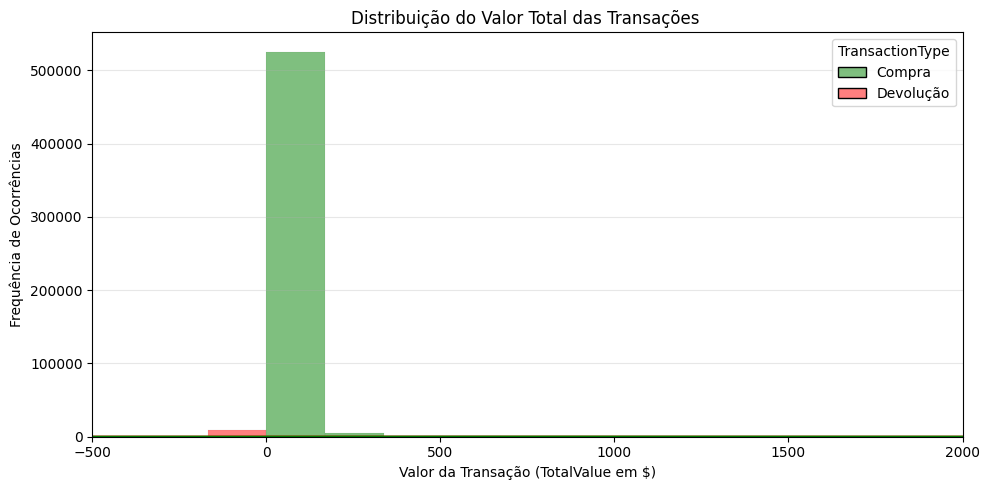

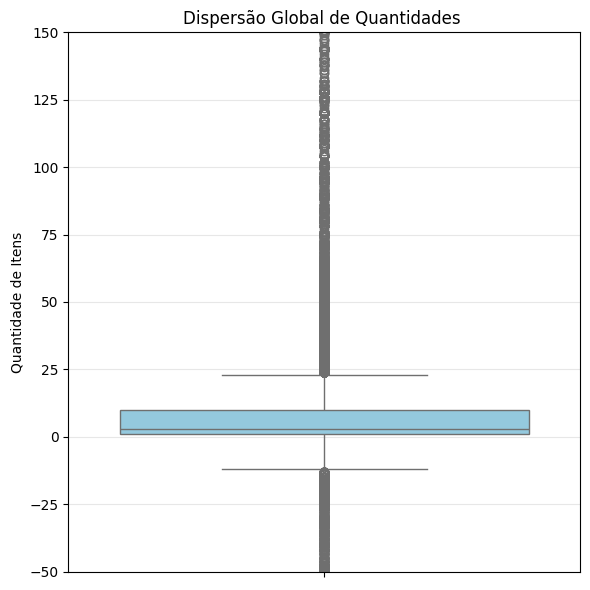

In [12]:
# Utilizamos a base completa em Pandas
df_pandas = df_base.to_pandas()


# GRÁFICO Histograma do Valor Total 

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_pandas, 
    x='TotalValue', 
    hue='TransactionType', 
    bins=2000,  
    kde=True, 
    palette={'Compra': 'green', 'Devolução': 'red'}
)


plt.xlim(-500, 2000) 

plt.title('Distribuição do Valor Total das Transações ')
plt.xlabel('Valor da Transação (TotalValue em $)')
plt.ylabel('Frequência de Ocorrências')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()


plt.show()



# GRÁFICO Boxplot Geral de Quantidades

plt.figure(figsize=(6, 6))


sns.boxplot(
    data=df_pandas, 
    y='Quantity', 
    color='skyblue'
)


plt.ylim(-50, 150)

plt.title('Dispersão Global de Quantidades ')
plt.ylabel('Quantidade de Itens')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()


plt.show()

# Desenvolvimento de Modelo de Regressão Linear para Previsão de Dados

--- Resultados da Regressão Linear ---
Equação da Reta: Y = 1.5402X + 3.2756
Inclinação (a): 1.5402 (Indica a variação do valor por unidade vendida)
Intercepto (b): 3.2756 (Valor inicial estimado quando a quantidade é zero)
R² (Coeficiente de Determinação): 0.7862 (78.62%)
MSE (Erro Quadrático Médio): 30679.2570


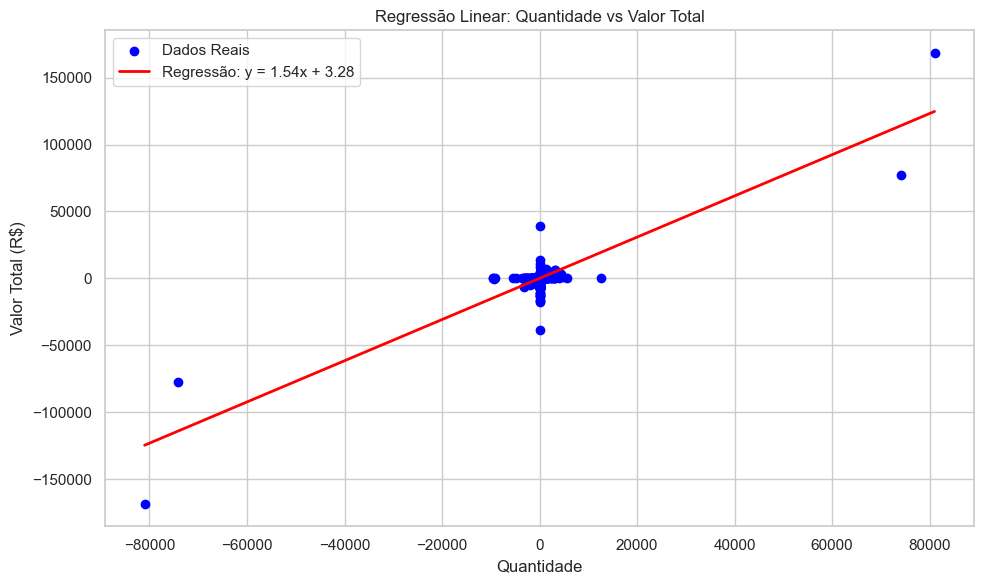

In [ ]:


arquivo_parquet = r"C:\Users\bruno\Desktop\olist-data-analysis\data-Science-Olist\data.parquet"
lazy_df = pl.scan_parquet(arquivo_parquet)



dados = (
    lazy_df
    .with_columns(
        (pl.col("Quantity") * pl.col("UnitPrice")).alias("Total_Value")
    )
    .select([
        pl.col("Quantity").cast(pl.Float64),
        pl.col("Total_Value").cast(pl.Float64)
    ])
    .drop_nulls()
    .collect()
)


X = dados["Quantity"].to_numpy().reshape(-1, 1)
y = dados["Total_Value"].to_numpy()


modelo = LinearRegression()
modelo.fit(X, y)


y_pred = modelo.predict(X)

a = modelo.coef_[0]  # Inclinação da reta 
b = modelo.intercept_  # Intercepto 

 
r2 = modelo.score(X, y)
mse = np.mean((y - y_pred) ** 2)


print("--- Resultados da Regressão Linear ---")
print(f"Equação da Reta: Y = {a:.4f}X + {b:.4f}")
print(f"Inclinação (a): {a:.4f} (Indica a variação do valor por unidade vendida)")
print(f"Intercepto (b): {b:.4f} (Valor inicial estimado quando a quantidade é zero)")
print(f"R² (Coeficiente de Determinação): {r2:.4f} ({r2 * 100:.2f}%)")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}")



# Visualização dos resultados
plt.figure(figsize=(10, 6))


plt.scatter(X, y, color='blue', label='Dados Reais')


plt.plot(X, y_pred, color='red', linewidth=2, label=f'Regressão: y = {a:.2f}x + {b:.2f}')

# Configurações do gráfico
plt.title('Regressão Linear: Quantidade vs Valor Total')
plt.xlabel('Quantidade')
plt.ylabel('Valor Total (R$)')
plt.grid(True)
plt.legend()

# Mostrar gráfico
plt.tight_layout()
plt.show()